To make this model work, we need to do the following: 
* For all crashes in our study area (Oakland + Berkeley), we need to mark whether a crash is associated with a traffic island and signal
* We need to determine which other explanatory variables to include in the model:
    * Traffic signal presence (OSM)
    * Traffic refuge island presence (OSM)
    * Number of lanes (TBD)
        * Looks like you have to play with the overpass API to get this data from OSM https://stackoverflow.com/questions/56558717/query-all-roads-with-overpass-api-and-export-as-polygon
    * Ped characteristics (gender, age, etc.) (retrieve from SWITRS)
        * **How do we do this if ped characteristics are tied to crash party but we want to look at crashes overall?**
    * AADT (From replica)
    * Functional classification of road as a proxy for speed
    * Day of the week (SWITRS)
    * Lighting at intersection (TBD, possibly on OSM)

In [377]:
import pandas as pd
import numpy as np
from statsmodels.miscmodels.ordinal_model import OrderedModel
# from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean data

In [378]:
# Load dataset
file_path = "crash_data_for_model.csv"  # Update with the actual file path
df = pd.read_csv(file_path, dtype=str)

In [379]:
# Remove irrelevant columns

df = df[[
        'COLLISION_SEVERITY',
        'AT_FAULT', # No should be reference
        'PARTY_SEX', # Male should be reference
        'PARTY_AGE',
        'RACE', # White should be reference
        'LIGHTING', # Daylight should be reference
        'DAY_OF_WEEK',
        'WEATHER_1', # Clear should be reference
        'PRIMARY_COLL_FACTOR', # Make dummy for A - Vehicle Code Violation
        'PCF_VIOL_CATEGORY',
        'PED_ACTION', # B - Crossing in Crosswalk at Intersection should be reference
        'PARTY_NUMBER_KILLED',
        'PARTY_NUMBER_INJURED',
        'road_class',
        'road_class_name',
        'island_id', # Convert to 1/0
        'volume', 
        'signal_id' # Convert to 1/0
]]

## Check for blanks or missing information

In [380]:
df.columns

Index(['COLLISION_SEVERITY', 'AT_FAULT', 'PARTY_SEX', 'PARTY_AGE', 'RACE',
       'LIGHTING', 'DAY_OF_WEEK', 'WEATHER_1', 'PRIMARY_COLL_FACTOR',
       'PCF_VIOL_CATEGORY', 'PED_ACTION', 'PARTY_NUMBER_KILLED',
       'PARTY_NUMBER_INJURED', 'road_class', 'road_class_name', 'island_id',
       'volume', 'signal_id'],
      dtype='object')

In [381]:
for col in df.columns: 
    print(df[col].value_counts(dropna=False))

COLLISION_SEVERITY
3    288
4    285
2     84
1     13
Name: count, dtype: int64
AT_FAULT
N    610
Y     60
Name: count, dtype: int64
PARTY_SEX
M    343
F    318
-      8
X      1
Name: count, dtype: int64
PARTY_AGE
20    23
19    22
30    17
23    17
18    17
      ..
0      1
8      1
89     1
1      1
91     1
Name: count, Length: 87, dtype: int64
RACE
B      197
W      175
H      128
A       76
O       55
NaN     39
Name: count, dtype: int64
LIGHTING
A    421
C    195
B     30
D     12
E      6
-      6
Name: count, dtype: int64
DAY_OF_WEEK
5    123
3    110
1    102
4     94
2     93
6     82
7     66
Name: count, dtype: int64
WEATHER_1
A    558
B     56
C     41
-     13
F      1
E      1
Name: count, dtype: int64
PRIMARY_COLL_FACTOR
A    639
D     26
B      2
C      2
-      1
Name: count, dtype: int64
PCF_VIOL_CATEGORY
10    442
11     62
08     46
00     29
12     28
03     22
21     15
17      6
09      5
01      5
-       3
05      2
22      2
18      2
07      1
Name: count

## Recode variables and create dummy variables

In [382]:
def remap_severity(severity_series):
    # Convert severity values to numeric, coercing errors to NaN
    severity_numeric = pd.to_numeric(severity_series, errors="coerce")
    # Define the mapping from original to reversed scale
    severity_mapping = {1: 4, 2: 3, 3: 2, 4: 1}
    remapped = severity_numeric.map(severity_mapping)
    # Define the order for the categorical variable
    severity_order = [1, 2, 3, 4]
    return pd.Categorical(remapped, categories=severity_order, ordered=True)

# Apply severity remapping using the dedicated function
df["COLLISION_SEVERITY"] = remap_severity(df["COLLISION_SEVERITY"])

In [383]:
# Recode day of the week category
print(df['DAY_OF_WEEK'].value_counts())
df['weekend'] = df["DAY_OF_WEEK"].apply(lambda x: "0" if x in ["1", "2", "3", "4"] else "1")
    # Include Friday because it often features in weekend crashes
df = df.drop('DAY_OF_WEEK', axis=1)
df['weekend'].value_counts()

DAY_OF_WEEK
5    123
3    110
1    102
4     94
2     93
6     82
7     66
Name: count, dtype: int64


weekend
0    399
1    271
Name: count, dtype: int64

In [384]:
# Recode at fault category
fault_dict = {'N':0, 'Y':1}
df['AT_FAULT'] = df['AT_FAULT'].map(fault_dict)
df['AT_FAULT'].value_counts()

AT_FAULT
0    610
1     60
Name: count, dtype: int64

In [385]:
# Recode island data
print(df['island_id'].value_counts().sum())
df['island_id'] = df['island_id'].notna()#.astype(int)
df['island_id'] = df['island_id'].map(int)
print(df['island_id'].value_counts())


36
island_id
0    634
1     36
Name: count, dtype: int64


In [386]:
# Recode signal data
print(df['signal_id'].value_counts().sum())
df['signal_id'] = df['signal_id'].notna()#.astype(int)
df['signal_id'] = df['signal_id'].map(int)
print(df['signal_id'].value_counts())

169
signal_id
0    501
1    169
Name: count, dtype: int64


In [387]:
# Recode ped_action data
print(df['PED_ACTION'].value_counts())
df.loc[df['PED_ACTION']!='B', 'ped_in_xwalk'] = 0
df.loc[df['PED_ACTION']=='B', 'ped_in_xwalk'] = 1 # B - Crossing in Crosswalk at Intersection
df = df.drop('PED_ACTION', axis=1)
df['ped_in_xwalk'].value_counts()

PED_ACTION
B    511
E     53
F     37
D     35
C     27
-      6
G      1
Name: count, dtype: int64


ped_in_xwalk
1.0    511
0.0    159
Name: count, dtype: int64

In [388]:
# Recode primary collision factor data
# print(df['PRIMARY_COLL_FACTOR'].value_counts())
# df.loc[df['PRIMARY_COLL_FACTOR']!='A', 'PRIMARY_COLL_FACTOR'] = 0
# df.loc[df['PRIMARY_COLL_FACTOR']=='A', 'PRIMARY_COLL_FACTOR'] = 1 # A - (Vehicle) Code Violation
# df['PRIMARY_COLL_FACTOR'].value_counts()

In [389]:
# Recode primary collision factor data
print(df['PCF_VIOL_CATEGORY'].value_counts())
df.loc[(df['PCF_VIOL_CATEGORY']!='09')|(df['PCF_VIOL_CATEGORY']!='11'), 'ped_violation_or_auto_row'] = 0
df.loc[(df['PCF_VIOL_CATEGORY']=='09')|(df['PCF_VIOL_CATEGORY']=='11'), 'ped_violation_or_auto_row'] = 1 
    # 09 - Automobile Right of Way
    # 10 - Pedestrian Right of Way
    # 11 - Pedestrian Violation 
    # 12 - Traffic Signals and Signs 
        # Maybe interact this with signal variable
    # 23 - Pedestrian or "Other" Under the Influence of Alcohol or Drug

df = df.drop('PCF_VIOL_CATEGORY', axis=1)
df['ped_violation_or_auto_row'].value_counts()

PCF_VIOL_CATEGORY
10    442
11     62
08     46
00     29
12     28
03     22
21     15
17      6
09      5
01      5
-       3
05      2
22      2
18      2
07      1
Name: count, dtype: int64


ped_violation_or_auto_row
0.0    603
1.0     67
Name: count, dtype: int64

In [390]:
# Recode weather data
print(df['WEATHER_1'].value_counts())
df.loc[df['WEATHER_1']!='A', 'WEATHER_1'] = 0
df.loc[df['WEATHER_1']=='A', 'WEATHER_1'] = 1 # A - Clear
df['WEATHER_1'].value_counts()

WEATHER_1
A    558
B     56
C     41
-     13
F      1
E      1
Name: count, dtype: int64


WEATHER_1
1    558
0    112
Name: count, dtype: int64

In [391]:
# Recode lighting data
print(df['LIGHTING'].value_counts())

# df.loc[df['LIGHTING']!='A', 'LIGHTING'] = 0
# df.loc[df['LIGHTING']=='A', 'LIGHTING'] = 1 # A - Daylight
# df['LIGHTING'].value_counts()

fault_dict = {
    'A': 'daylight',
    'C': 'streetlight', 
    'B': 'dusk_dawn',
    'D': 'no_streetlight',
    'E': 'no_streetlight',
    '-': '-'
}
df['LIGHTING'] = df['LIGHTING'].map(fault_dict)
df['LIGHTING'] = df['LIGHTING'].mask(df['LIGHTING']=='-', np.nan)
df['LIGHTING'].value_counts(dropna=False)

LIGHTING
A    421
C    195
B     30
D     12
E      6
-      6
Name: count, dtype: int64


LIGHTING
daylight          421
streetlight       195
dusk_dawn          30
no_streetlight     18
NaN                 6
Name: count, dtype: int64

In [392]:
# Recode road class
print(df['road_class_name'].value_counts(dropna=False))

# Remove rows with 1 and 2 because these are highways/freeways
df.drop(df[df['road_class_name'] == 'interstate'].index, inplace=True)
df.drop(df[df['road_class_name'] == 'other fwy or expwy'].index, inplace=True)
print(df['road_class_name'].value_counts(dropna=False))

# Create dummy for minor arterial vs. other principal arterial
df.loc[(df['road_class_name']=='minor arterial'), 'road_class'] = 0 
df.loc[(df['road_class_name']=='other principal arterial'), 'road_class'] = 1 
# we may drop these ones:
df.loc[(df['road_class_name']=='major collector')|(df['road_class_name']=='local'), 'road_class'] = 2 

print(df['road_class'].value_counts(dropna=False))


road_class_name
minor arterial              215
other principal arterial    192
local                       189
major collector              66
interstate                    7
other fwy or expwy            1
Name: count, dtype: int64
road_class_name
minor arterial              215
other principal arterial    192
local                       189
major collector              66
Name: count, dtype: int64
road_class
2    255
0    215
1    192
Name: count, dtype: int64


In [393]:
# Recode party_sex
df['PARTY_SEX'].value_counts()

# Convert blanks and the one X value to NaN
df['PARTY_SEX'] = df['PARTY_SEX'].mask((df['PARTY_SEX']=='-')|(df['PARTY_SEX']=='X'), np.nan)


In [394]:
# Apply dummy encoding
df = pd.get_dummies(df, columns=[
    'PARTY_SEX', # Male should be reference
    'RACE', # White should be reference
    'LIGHTING'
    ], drop_first=True)

display(df)

,COLLISION_SEVERITY,AT_FAULT,PARTY_AGE,WEATHER_1,PRIMARY_COLL_FACTOR,PARTY_NUMBER_KILLED,PARTY_NUMBER_INJURED,road_class,road_class_name,island_id,...,ped_in_xwalk,ped_violation_or_auto_row,PARTY_SEX_M,RACE_B,RACE_H,RACE_O,RACE_W,LIGHTING_dusk_dawn,LIGHTING_no_streetlight,LIGHTING_streetlight
0,1,0,60,0,A,0,1,0,minor arterial,0,...,1.0,0.0,True,False,False,False,True,False,False,False
1,1,0,57,1,A,0,1,2,major collector,0,...,1.0,0.0,True,True,False,False,False,False,False,False
2,2,0,30,1,A,0,1,2,major collector,0,...,1.0,0.0,False,False,True,False,False,False,False,True
3,2,1,13,1,A,0,1,2,major collector,0,...,1.0,1.0,False,False,True,False,False,False,False,False
4,1,0,23,1,A,0,1,2,local,0,...,0.0,0.0,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
665,2,0,45,1,A,0,1,0,minor arterial,0,...,1.0,0.0,False,False,False,False,True,False,False,False
666,3,0,77,1,A,0,1,2,major collector,0,...,1.0,0.0,False,False,False,False,True,False,False,False
667,2,0,42,1,A,0,1,0,minor arterial,0,...,1.0,0.0,False,False,False,False,True,False,False,False
668,1,0,38,0,A,0,1,0,minor arterial,0,...,1.0,0.0,True,False,False,False,True,False,False,True


# Reduce sample based on road classification

In [395]:
df['road_class_name'].value_counts()

road_class_name
minor arterial              215
other principal arterial    192
local                       189
major collector              66
Name: count, dtype: int64

In [396]:
pd.crosstab(df['road_class_name'], df['island_id'])

island_id,0,1
road_class_name,,
local,186,3
major collector,66,0
minor arterial,202,13
other principal arterial,172,20


In [397]:
# We could drop local roads, but then we'd lose three crashes
# Instead, let's just drop major collector and see what happens
df.drop(df[df['road_class_name'] == 'major collector'].index, inplace=True)

# Okay so that didn't seem to change much, so let's try dropping local roads too
df.drop(df[df['road_class_name'] == 'local'].index, inplace=True)

df.shape

# Woah okay when we remove local roads, the psuedo R^2 value increase by more than 0.01 and the log likelihood increase by 200 (-600 to -400)

(407, 23)

# Select final variables for model

In [398]:
df.columns

Index(['COLLISION_SEVERITY', 'AT_FAULT', 'PARTY_AGE', 'WEATHER_1',
       'PRIMARY_COLL_FACTOR', 'PARTY_NUMBER_KILLED', 'PARTY_NUMBER_INJURED',
       'road_class', 'road_class_name', 'island_id', 'volume', 'signal_id',
       'weekend', 'ped_in_xwalk', 'ped_violation_or_auto_row', 'PARTY_SEX_M',
       'RACE_B', 'RACE_H', 'RACE_O', 'RACE_W', 'LIGHTING_dusk_dawn',
       'LIGHTING_no_streetlight', 'LIGHTING_streetlight'],
      dtype='object')

In [399]:
df = df[[
    'COLLISION_SEVERITY', 'AT_FAULT', 'PARTY_AGE', 'WEATHER_1',
    'island_id', 'volume', 'signal_id', 'weekend', 'ped_in_xwalk', 'ped_violation_or_auto_row',
    'road_class', 'PARTY_SEX_M', 'RACE_B', 'RACE_H',
    'RACE_O', 'RACE_W', 'LIGHTING_dusk_dawn', 'LIGHTING_no_streetlight',
    'LIGHTING_streetlight'
]]

# Fix data types

In [400]:
df.dtypes

COLLISION_SEVERITY           category
AT_FAULT                        int64
PARTY_AGE                      object
WEATHER_1                      object
island_id                       int64
volume                         object
signal_id                       int64
weekend                        object
ped_in_xwalk                  float64
ped_violation_or_auto_row     float64
road_class                     object
PARTY_SEX_M                      bool
RACE_B                           bool
RACE_H                           bool
RACE_O                           bool
RACE_W                           bool
LIGHTING_dusk_dawn               bool
LIGHTING_no_streetlight          bool
LIGHTING_streetlight             bool
dtype: object

In [401]:
cols = ['PARTY_AGE', 
        'WEATHER_1',
        'weekend'
        ]

df[cols] = df[cols].astype(int)

df['volume'] = df['volume'].astype(float)
df['volume'] = df['volume'].fillna(0).astype(int)
# lets scale the volumes between 0 and 1 so they aren't such ridiculous numeric outliers
max_value = df['volume'].max()
df['volume'] = df['volume']/max_value

# let's convert all the True/False into 1/0
for col in df:
    if df[col].dtype == bool:
        df[col] = df[col].map(int)
for col in df:
    if df[col].dtype == object:
        df[col] = df[col].map(int)

df.dtypes

COLLISION_SEVERITY           category
AT_FAULT                        int64
PARTY_AGE                       int64
WEATHER_1                       int64
island_id                       int64
volume                        float64
signal_id                       int64
weekend                         int64
ped_in_xwalk                  float64
ped_violation_or_auto_row     float64
road_class                      int64
PARTY_SEX_M                     int64
RACE_B                          int64
RACE_H                          int64
RACE_O                          int64
RACE_W                          int64
LIGHTING_dusk_dawn              int64
LIGHTING_no_streetlight         int64
LIGHTING_streetlight            int64
dtype: object

# Fix data types

In [402]:
df.dtypes

COLLISION_SEVERITY           category
AT_FAULT                        int64
PARTY_AGE                       int64
WEATHER_1                       int64
island_id                       int64
volume                        float64
signal_id                       int64
weekend                         int64
ped_in_xwalk                  float64
ped_violation_or_auto_row     float64
road_class                      int64
PARTY_SEX_M                     int64
RACE_B                          int64
RACE_H                          int64
RACE_O                          int64
RACE_W                          int64
LIGHTING_dusk_dawn              int64
LIGHTING_no_streetlight         int64
LIGHTING_streetlight            int64
dtype: object

In [403]:
cols = ['PARTY_AGE', 
        'WEATHER_1',
        'weekend'
        ]

df[cols] = df[cols].astype(int)

df['volume'] = df['volume'].astype(float)
# df['volume'] = df['volume'].fillna(0).astype(int)
# lets scale the volumes between 0 and 1 so they aren't such ridiculous numeric outliers
# max_value = df['volume'].max()
# print("max volume:" + max_value)
# df['volume'] = df['volume']/max_value

# let's convert all the True/False into 1/0
for col in df:
    if df[col].dtype == bool:
        df[col] = df[col].map(int)
for col in df:
    if df[col].dtype == object:
        df[col] = df[col].map(int)

df.dtypes

COLLISION_SEVERITY           category
AT_FAULT                        int64
PARTY_AGE                       int64
WEATHER_1                       int64
island_id                       int64
volume                        float64
signal_id                       int64
weekend                         int64
ped_in_xwalk                  float64
ped_violation_or_auto_row     float64
road_class                      int64
PARTY_SEX_M                     int64
RACE_B                          int64
RACE_H                          int64
RACE_O                          int64
RACE_W                          int64
LIGHTING_dusk_dawn              int64
LIGHTING_no_streetlight         int64
LIGHTING_streetlight            int64
dtype: object

# Correlation matrices

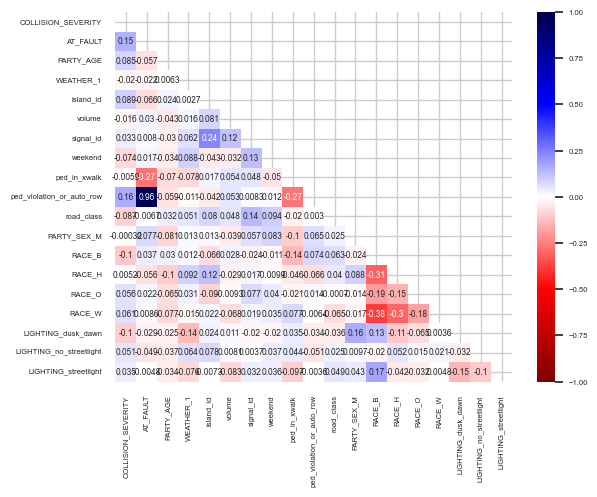

In [404]:
#Create heatmap of correlations among the variables
sns.set(context='notebook', style='whitegrid', font_scale=0.5)
upper = np.triu(df.corr())  # Here, we are looking at the upper triangle. Optionally, you can just look at the lower triangle. 
sns.heatmap(df.corr(), cmap="seismic_r", annot=True, vmin=-1, vmax=1, mask=upper);
plt.savefig('heatmap.png')

# Select final variables for model

In [405]:
df.columns

Index(['COLLISION_SEVERITY', 'AT_FAULT', 'PARTY_AGE', 'WEATHER_1', 'island_id',
       'volume', 'signal_id', 'weekend', 'ped_in_xwalk',
       'ped_violation_or_auto_row', 'road_class', 'PARTY_SEX_M', 'RACE_B',
       'RACE_H', 'RACE_O', 'RACE_W', 'LIGHTING_dusk_dawn',
       'LIGHTING_no_streetlight', 'LIGHTING_streetlight'],
      dtype='object')

In [406]:
df = df[[
    'COLLISION_SEVERITY', 'AT_FAULT', 'PARTY_AGE', 'WEATHER_1',
    'island_id', 'volume', 'signal_id', 'weekend', 'ped_in_xwalk', 'ped_violation_or_auto_row',
    'road_class', 'PARTY_SEX_M', 'RACE_B', 'RACE_H',
    'RACE_O', 'RACE_W', 'LIGHTING_dusk_dawn', 'LIGHTING_no_streetlight',
    'LIGHTING_streetlight'
]]

# Run model

In [407]:
# Define independent variables (all columns except the target)
independent_vars = df.columns.difference(['COLLISION_SEVERITY'])

independent_vars

Index(['AT_FAULT', 'LIGHTING_dusk_dawn', 'LIGHTING_no_streetlight',
       'LIGHTING_streetlight', 'PARTY_AGE', 'PARTY_SEX_M', 'RACE_B', 'RACE_H',
       'RACE_O', 'RACE_W', 'WEATHER_1', 'island_id', 'ped_in_xwalk',
       'ped_violation_or_auto_row', 'road_class', 'signal_id', 'volume',
       'weekend'],
      dtype='object')

In [408]:
df.head()
    df['road_class'].value_counts()

road_class
0    215
1    192
Name: count, dtype: int64

In [409]:
# Specify and calibrate the Ordered Logit Model
model = OrderedModel(
    endog=df["COLLISION_SEVERITY"],
    exog=df[independent_vars],
    distr="logit"
)

# I tried some different model methods. I think we may have too many un-useful independent variables
# result = model.fit(method="cg")
# result = model.fit(method="nm")
result = model.fit(method="bfgs")
print(result.summary())

Optimization terminated successfully.
         Current function value: 1.029197
         Iterations: 102
         Function evaluations: 106
         Gradient evaluations: 106
                             OrderedModel Results                             
Dep. Variable:     COLLISION_SEVERITY   Log-Likelihood:                -418.88
Model:                   OrderedModel   AIC:                             879.8
Method:            Maximum Likelihood   BIC:                             964.0
Date:                Tue, 21 Apr 2026                                         
Time:                        16:11:43                                         
No. Observations:                 407                                         
Df Residuals:                     386                                         
Df Model:                          18                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
--------------------

In [410]:
print("Psuedo r^2 value:", result.prsquared)  # Access McFadden's Pseudo R2

Psuedo r^2 value: 0.039465241461755785


In [411]:
# Compute and display Odds Ratios
odds_ratios = np.exp(result.params)
print("\nOdds Ratios:\n", odds_ratios)

# Predict probabilities for each severity level
predicted_probs = result.predict()

# Convert predictions to a DataFrame
predicted_probs_df = pd.DataFrame(predicted_probs)

# Determine the most likely severity level for each observation
df["Predicted_Severity"] = predicted_probs_df.idxmax(axis=1)

# Display performance metrics with a confusion matrix (objective results only)
confusion_matrix = pd.crosstab(df["COLLISION_SEVERITY"], df["Predicted_Severity"],
                               rownames=['Actual'], colnames=['Predicted'])
print("\nConfusion Matrix:\n", confusion_matrix)



Odds Ratios:
 AT_FAULT                     2.514200
LIGHTING_dusk_dawn           0.385122
LIGHTING_no_streetlight      2.086433
LIGHTING_streetlight         1.080447
PARTY_AGE                    1.001544
PARTY_SEX_M                  1.083329
RACE_B                       0.784158
RACE_H                       1.059443
RACE_O                       1.864019
RACE_W                       1.439978
WEATHER_1                    0.945275
island_id                    1.742457
ped_in_xwalk                 1.273344
ped_violation_or_auto_row    1.128424
road_class                   0.711143
signal_id                    1.154765
volume                       0.709647
weekend                      0.809863
1/2                          0.983333
2/3                          2.179749
3/4                          2.083077
dtype: float64

Confusion Matrix:
 Predicted  0.0  1.0
Actual             
1           74   60
2           30   53
3           10   14
4            4    3


In [35]:
display(df)

,COLLISION_SEVERITY,AT_FAULT,PARTY_AGE,WEATHER_1,island_id,volume,signal_id,weekend,ped_in_xwalk,ped_violation_or_auto_row,local_collector_road_class,PARTY_SEX_M,RACE_B,RACE_H,RACE_O,RACE_W,LIGHTING_dusk_dawn,LIGHTING_no_streetlight,LIGHTING_streetlight,Predicted_Severity
0,1,0,60,0,0,0.0,0,0,1.0,0.0,0.0,1,0,0,0,1,0,0,0,1.0
6,1,0,60,1,0,0.0,0,0,0.0,0.0,0.0,1,1,0,0,0,1,0,0,1.0
7,1,0,68,1,0,0.0,0,0,0.0,0.0,0.0,1,1,0,0,0,1,0,0,1.0
8,2,0,60,1,0,0.0,0,0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,1.0
9,2,0,30,1,0,0.0,0,1,0.0,0.0,0.0,1,0,1,0,0,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
661,1,0,71,0,0,0.0,1,1,1.0,0.0,0.0,1,1,0,0,0,0,0,1,NaN
662,1,0,9,1,0,0.0,0,0,1.0,0.0,0.0,1,0,1,0,0,0,0,0,NaN
665,2,0,45,1,0,0.0,0,0,1.0,0.0,0.0,0,0,0,0,1,0,0,0,NaN
667,2,0,42,1,0,0.0,0,1,1.0,0.0,0.0,0,0,0,0,1,0,0,0,NaN
